In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [3]:
runways = pd.read_csv(
    "../../../data/processed/airports/runways/runways_processed.csv"
)

In [20]:
def standardize_surface(surface):

    if pd.isna(surface):
        return "UNKNOWN"

    surface = str(surface).upper().strip()

    if "ASP" in surface:
        return "ASPHALT"

    elif "CON" in surface:
        return "CONCRETE"

    elif ("GRASS" in surface) or ("TURF" in surface) or (surface == "GRS"):
        return "GRASS/TURF"

    elif ("GRVL" in surface) or ("GRAVEL" in surface):
        return "GRAVEL"

    elif ("DIRT" in surface) or ("EARTH" in surface) or ("SOIL" in surface):
        return "DIRT"

    elif "WATER" in surface:
        return "WATER"

    elif "SAND" in surface:
        return "SAND"

    elif ("SNOW" in surface) or ("ICE" in surface):
        return "SNOW/ICE"

    elif surface == "UNKNOWN":
        return "UNKNOWN"

    else:
        return "OTHER"

In [5]:
runways["surface_category"] = runways["surface"].apply(
    standardize_surface
)

In [21]:
def classify_runway_length(length):

    if length < 2500:
        return "Very Short"

    elif length < 5000:
        return "Short"

    elif length < 8000:
        return "Medium"

    elif length < 10000:
        return "Long"

    else:
        return "Very Long"

In [22]:
runways["runway_length_category"] = (
    runways["length_ft"]
    .apply(classify_runway_length)
)

In [23]:
def classify_width(width):

    if width < 50:
        return "Narrow"

    elif width < 100:
        return "Standard"

    elif width < 150:
        return "Wide"

    else:
        return "Very Wide"

In [24]:
runways["runway_width_category"] = (
    runways["width_ft"]
    .apply(classify_width)
)

In [25]:
runways["night_operation"] = np.where(
    runways["lighted"] == 1,
    "Yes",
    "No"
)

In [26]:
runways["operational_status"] = np.where(
    runways["closed"] == 1,
    "Closed",
    "Operational"
)

In [27]:
def runway_capability(row):

    if (
        row["length_ft"] >= 8000
        and row["lighted"] == 1
        and row["closed"] == 0
    ):
        return "High"

    elif (
        row["length_ft"] >= 5000
        and row["closed"] == 0
    ):
        return "Medium"

    else:
        return "Basic"

In [28]:
runways["runway_capability"] = (
    runways.apply(runway_capability, axis=1)
)

In [29]:
def runway_risk(row):

    if row["closed"] == 1:
        return "High"

    elif (
        row["lighted"] == 0
        and row["length_ft"] < 5000
    ):
        return "Medium"

    else:
        return "Low"

In [30]:
runways["runway_risk_level"] = (
    runways.apply(runway_risk, axis=1)
)

In [31]:
new_features = [

    "surface_category",

    "runway_length_category",

    "runway_width_category",

    "night_operation",

    "operational_status",

    "runway_capability",

    "runway_risk_level"

]

runways[new_features].head()

,surface_category,runway_length_category,runway_width_category,night_operation,operational_status,runway_capability,runway_risk_level
0,ASPHALT,Very Short,Standard,Yes,Operational,Basic,Low
1,GRAVEL,Short,Narrow,No,Operational,Basic,Medium
2,GRASS/TURF,Very Short,Standard,No,Operational,Basic,Medium
3,OTHER,Short,Standard,No,Operational,Basic,Medium
4,GRASS/TURF,Very Short,Standard,No,Operational,Basic,Medium


In [32]:
for feature in new_features:

    print(f"\n{'='*50}")
    print(feature.upper())
    print('='*50)

    print(runways[feature].value_counts())

    print("\n")


SURFACE_CATEGORY
surface_category
ASPHALT       15305
GRASS/TURF    14931
CONCRETE       7397
OTHER          6406
DIRT           1516
GRAVEL         1151
WATER           784
UNKNOWN         505
SAND             50
SNOW/ICE         29
Name: count, dtype: int64



RUNWAY_LENGTH_CATEGORY
runway_length_category
Very Short    20901
Short         18089
Medium         5372
Long           2110
Very Long      1602
Name: count, dtype: int64



RUNWAY_WIDTH_CATEGORY
runway_width_category
Standard     26411
Wide          9211
Narrow        6350
Very Wide     6102
Name: count, dtype: int64



NIGHT_OPERATION
night_operation
No     35754
Yes    12320
Name: count, dtype: int64



OPERATIONAL_STATUS
operational_status
Operational    47023
Closed          1051
Name: count, dtype: int64



RUNWAY_CAPABILITY
runway_capability
Basic     39291
Medium     6004
High       2779
Name: count, dtype: int64



RUNWAY_RISK_LEVEL
runway_risk_level
Medium    32184
Low       14839
High       1051
Name: count, dtype:

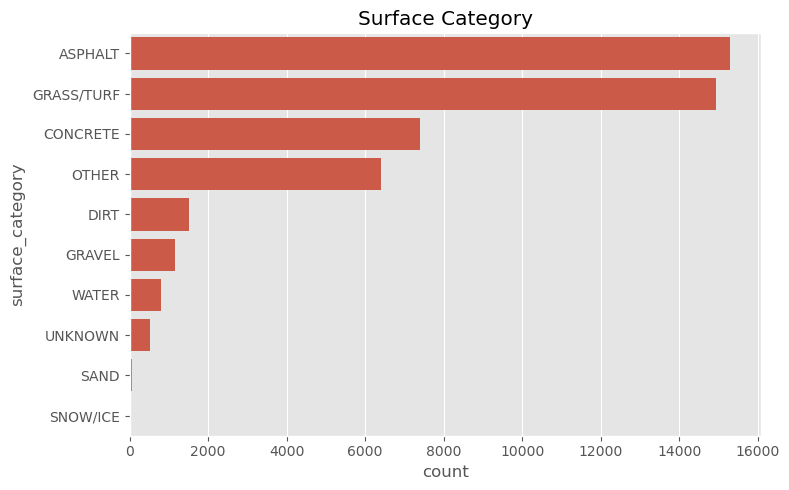

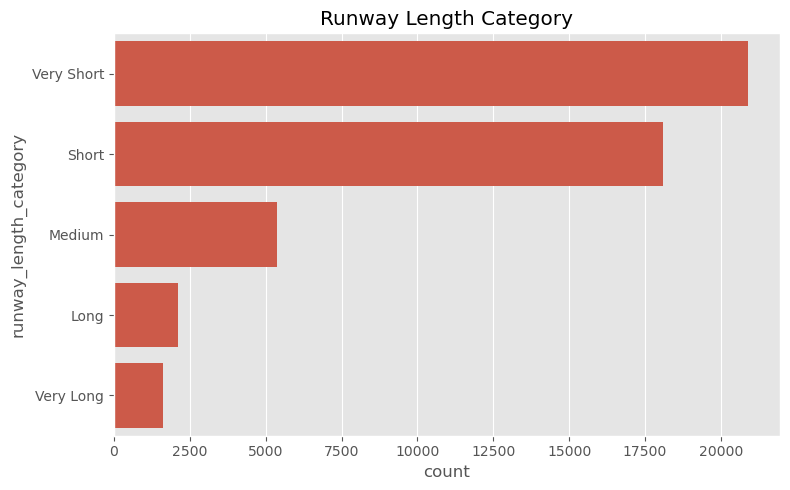

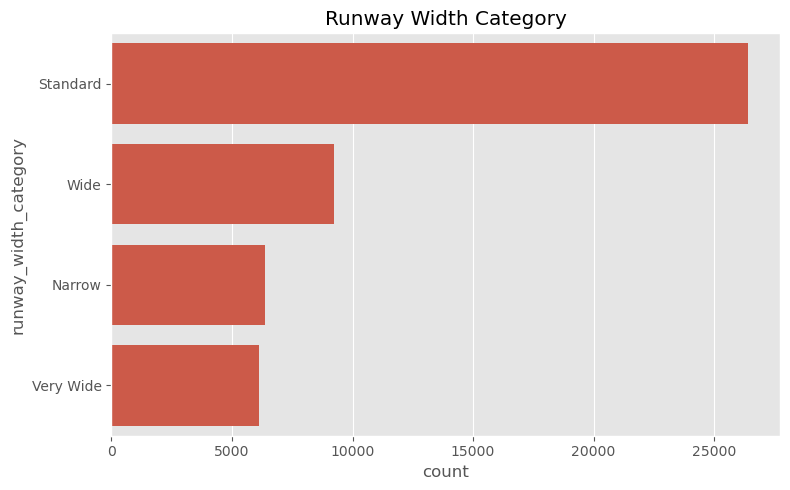

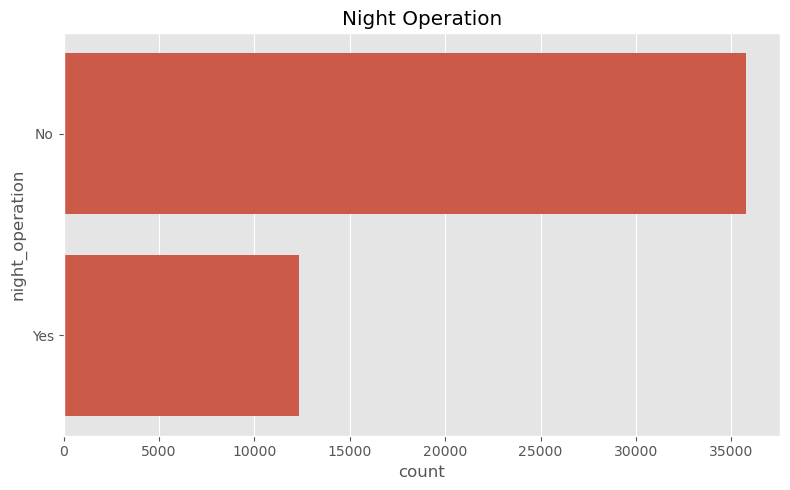

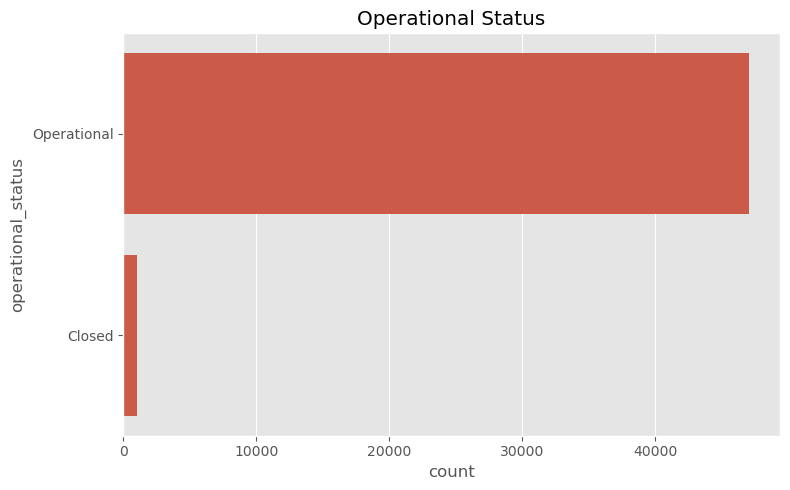

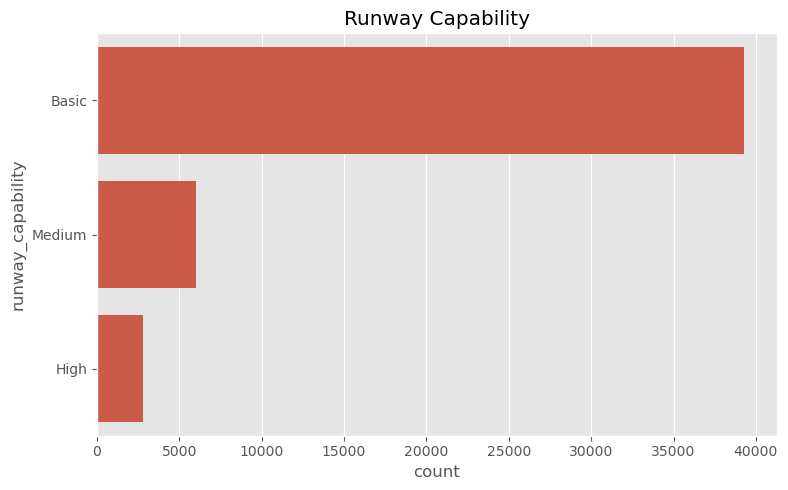

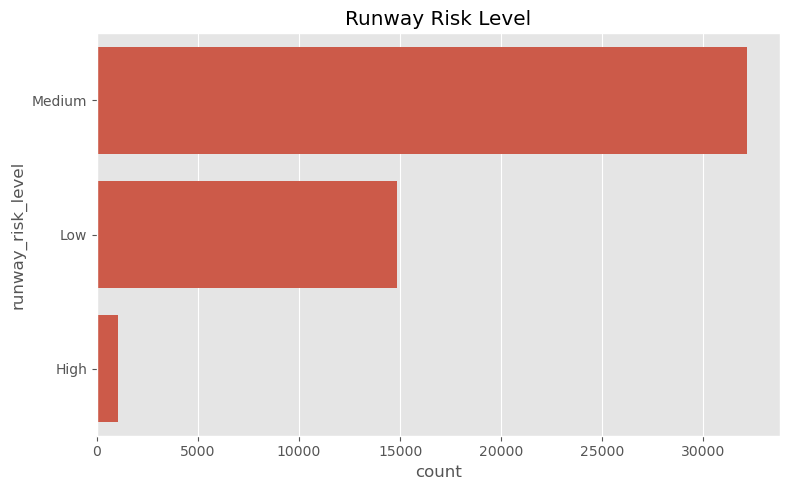

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

for feature in new_features:

    plt.figure(figsize=(8,5))

    sns.countplot(
        y=feature,
        data=runways,
        order=runways[feature].value_counts().index
    )

    plt.title(feature.replace("_", " ").title())

    plt.tight_layout()

    plt.show()

In [34]:
runways.to_csv(
    "../../../data/processed/airports/runways/runways_feature_engineered.csv",
    index=False
)

print("Runways feature-engineered dataset saved successfully.")

Runways feature-engineered dataset saved successfully.


## Feature Engineering Summary

Operational runway features were engineered to provide a higher-level representation of runway infrastructure while preserving the original operational attributes. A standardized runway surface category was created by grouping similar surface types into broader operational classes. Additional features describing runway length, runway width, night operation capability, operational status, runway capability, and runway risk level were derived using operationally meaningful rules based on runway characteristics. These engineered features provide a simplified yet informative representation of runway infrastructure and will later be integrated with airport information to support airport capability assessment, hybrid AI-based risk analysis, and the Flight Operations Analytics and Decision Support Dashboard.